In [ ]:
import json
import matplotlib.pyplot as plt
import pandas as pd
import psycopg2
import numpy as np
from pathlib import Path
from scipy.signal import medfilt

# Leer credenciales de ~/.cogni/config.json (mismo archivo que cogni-gui.py)
_CONFIG_PATH = Path.home() / ".cogni" / "config.json"
_cfg = json.loads(_CONFIG_PATH.read_text(encoding="utf-8"))
_db = _cfg["db"]

conn = psycopg2.connect(
    host=_db["host"],
    port=int(_db.get("port", 5432)),
    dbname=_db["dbname"],
    user=_db["user"],
    password=_db.get("password", ""),
)

query = """
    SELECT
    ts,
    time_elapsed,
    stimulus,
    -- S4 D12
    s4_d12_740nm_rp,
    s4_d12_740nm_lp,
    s4_d12_850nm_rp,
    s4_d12_850nm_lp,
    -- S4 D11
    s4_d11_740nm_rp,
    s4_d11_740nm_lp,
    s4_d11_850nm_rp,
    s4_d11_850nm_lp,
    -- S5 D12
    s5_d12_740nm_rp,
    s5_d12_740nm_lp,
    s5_d12_850nm_rp,
    s5_d12_850nm_lp,
    -- S5 D13
    s5_d13_740nm_rp,
    s5_d13_740nm_lp,
    s5_d13_850nm_rp,
    s5_d13_850nm_lp,
    -- S5 D15
    s5_d15_740nm_rp,
    s5_d15_740nm_lp,
    s5_d15_850nm_rp,
    s5_d15_850nm_lp,
    -- S1 D11
    s1_d11_740nm_rp,
    s1_d11_740nm_lp,
    s1_d11_850nm_rp,
    s1_d11_850nm_lp,
    -- S1 D9
    s1_d9_740nm_rp,
    s1_d9_740nm_lp,
    s1_d9_850nm_rp,
    s1_d9_850nm_lp,
    -- S3 D12
    s3_d12_740nm_rp,
    s3_d12_740nm_lp,
    s3_d12_850nm_rp,
    s3_d12_850nm_lp,
    -- S3 D11
    s3_d11_740nm_rp,
    s3_d11_740nm_lp,
    s3_d11_850nm_rp,
    s3_d11_850nm_lp,
    -- S3 D10
    s3_d10_740nm_rp,
    s3_d10_740nm_lp,
    s3_d10_850nm_rp,
    s3_d10_850nm_lp,
    -- S3 D15
    s3_d15_740nm_rp,
    s3_d15_740nm_lp,
    s3_d15_850nm_rp,
    s3_d15_850nm_lp,
    -- S7 D13
    s7_d13_740nm_rp,
    s7_d13_740nm_lp,
    s7_d13_850nm_rp,
    s7_d13_850nm_lp,
    -- S7 D15
    s7_d15_740nm_rp,
    s7_d15_740nm_lp,
    s7_d15_850nm_rp,
    s7_d15_850nm_lp,
    -- S7 D16
    s7_d16_740nm_rp,
    s7_d16_740nm_lp,
    s7_d16_850nm_rp,
    s7_d16_850nm_lp,
    -- S7 D14
    s7_d14_740nm_rp,
    s7_d14_740nm_lp,
    s7_d14_850nm_rp,
    s7_d14_850nm_lp,
    -- S2 D9
    s2_d9_740nm_rp,
    s2_d9_740nm_lp,
    s2_d9_850nm_rp,
    s2_d9_850nm_lp,
    -- S2 D11
    s2_d11_740nm_rp,
    s2_d11_740nm_lp,
    s2_d11_850nm_rp,
    s2_d11_850nm_lp,
    -- S2 D10
    s2_d10_740nm_rp,
    s2_d10_740nm_lp,
    s2_d10_850nm_rp,
    s2_d10_850nm_lp,
    -- S6 D10
    s6_d10_740nm_rp,
    s6_d10_740nm_lp,
    s6_d10_850nm_rp,
    s6_d10_850nm_lp,
    -- S6 D15
    s6_d15_740nm_rp,
    s6_d15_740nm_lp,
    s6_d15_850nm_rp,
    s6_d15_850nm_lp,
    -- S6 D14
    s6_d14_740nm_rp,
    s6_d14_740nm_lp,
    s6_d14_850nm_rp,
    s6_d14_850nm_lp,
    -- S8 D16
    s8_d16_740nm_rp,
    s8_d16_740nm_lp,
    s8_d16_850nm_rp,
    s8_d16_850nm_lp,
    -- S8 D14
    s8_d14_740nm_rp,
    s8_d14_740nm_lp,
    s8_d14_850nm_rp,
    s8_d14_850nm_lp
    FROM frames
    WHERE
        session_id = 'bbb7e4c5-46cd-42f5-8e66-1e303f30a01a'
    ORDER BY time_elapsed ASC
"""

raw_data = pd.read_sql(query, conn)


In [2]:
# Segmentar datos por transiciones de estímulo
raw_data['segment_id'] = (raw_data['stimulus'] != raw_data['stimulus'].shift()).cumsum()

df_baseline = raw_data[raw_data['stimulus'] == 0].copy()
df_active   = raw_data[raw_data['stimulus'] == 1].copy()

baseline_segments = [seg for _, seg in df_baseline.groupby('segment_id')]
active_segments   = [seg for _, seg in df_active.groupby('segment_id')]

print(f"Total segmentos: {raw_data['segment_id'].max()}")
print(f"Segmentos línea de base (stimulus=0): {len(baseline_segments)}")
print(f"Segmentos activos   (stimulus=1): {len(active_segments)}")

segment_summary = raw_data.groupby('segment_id').agg(
    stimulus=('stimulus', 'first'),
    t_start=('time_elapsed', 'min'),
    t_end=('time_elapsed', 'max'),
    n_samples=('time_elapsed', 'count')
).reset_index()
print(segment_summary.to_string(index=False))

Total segmentos: 5
Segmentos línea de base (stimulus=0): 3
Segmentos activos   (stimulus=1): 2
 segment_id  stimulus    t_start      t_end  n_samples
          1         0   0.445521  23.035076        103
          2         1  23.245538  98.426816        340
          3         0  98.667204 141.118383        193
          4         1 141.356875 178.589893        168
          5         0 178.798209 189.900013         51


In [3]:
# Extraer todos los pares fuente-detector presentes en las columnas
pairs = sorted(set(
    col.replace('_740nm_rp', '')
    for col in raw_data.columns
    if col.endswith('_740nm_rp')
))

print(f"Pares encontrados: {len(pairs)}")
for p in pairs:
    print(f"  {p.upper().replace('_', ' ')}")

Pares encontrados: 23
  S1 D11
  S1 D9
  S2 D10
  S2 D11
  S2 D9
  S3 D10
  S3 D11
  S3 D12
  S3 D15
  S4 D11
  S4 D12
  S5 D12
  S5 D13
  S5 D15
  S6 D10
  S6 D14
  S6 D15
  S7 D13
  S7 D14
  S7 D15
  S7 D16
  S8 D14
  S8 D16


In [4]:
# ── Parámetros de procesamiento ───────────────────────────────────────────────
MEDIAN_KERNEL    = 11   # tamaño del kernel del filtro de mediana
BASELINE_SEGMENT = 3    # segment_id usado como referencia para calcular μ

# ── Ley de Beer-Lambert Modificada (MBLL) ─────────────────────────────────────
# Coeficientes de extinción molar (mM⁻¹ cm⁻¹) — compilación Cope/Prahl/Gratzer
# (los valores extraídos del PDF del paper están corruidos; estos son los
#  valores estándar de la literatura para 740 nm y 850 nm)
EPS_HBO2_740 = 0.4526    # ε HbO₂ a 740 nm
EPS_HB_740   = 1.1504    # ε Hb   a 740 nm
EPS_HBO2_850 = 1.0580    # ε HbO₂ a 850 nm
EPS_HB_850   = 0.6913    # ε Hb   a 850 nm

# DPF (Diffuse Path-length Factor) — Scholkmann et al. para frente
# (paper: DPF_740 = 6.25, DPF_850 = 4.89)
DPF_740 = 6.25
DPF_850 = 4.89

# Distancia fuente-detector para canales largos (cm)
L_SD = 3.0   # 30 mm

# Matriz E y su inversa (precalculada una sola vez)
E_MATRIX = np.array([
    [EPS_HBO2_740 * DPF_740 * L_SD,  EPS_HB_740 * DPF_740 * L_SD],
    [EPS_HBO2_850 * DPF_850 * L_SD,  EPS_HB_850 * DPF_850 * L_SD],
])
E_INV = np.linalg.inv(E_MATRIX)

print("Matriz E (ε·DPF·L):")
print(E_MATRIX)
print(f"\ndet(E) = {np.linalg.det(E_MATRIX):.4f}")
print(f"\nE⁻¹:\n{E_INV}")

# ── Helpers ───────────────────────────────────────────────────────────────────
def get_stimulus_spans(df):
    """Devuelve lista de (t_start, t_end) para cada bloque con stimulus=1."""
    spans = []
    for _, grp in df.groupby('segment_id'):
        if grp['stimulus'].iloc[0] == 1:
            spans.append((grp['time_elapsed'].min(), grp['time_elapsed'].max()))
    return spans


def shade_stimulus(ax, spans, first_only_label=True):
    """Sombrea las regiones de estímulo activo sobre un eje."""
    for i, (t0, t1) in enumerate(spans):
        lbl = 'Estímulo' if (first_only_label and i == 0) else '_nolegend_'
        ax.axvspan(t0, t1, color='gray', alpha=0.25, label=lbl)


def process_pair(df, pair):
    """
    Para un par fuente-detector dado aplica:
      1. Filtro de mediana (orden MEDIAN_KERNEL)
      2. Densidad óptica: OD = -log10(V / μ)
      3. MBLL: [ΔHbO₂, ΔHb]ᵀ = E⁻¹ · [OD_740, OD_850]ᵀ

    Retorna dict con 'raw', 'filt', 'od', 'hbo2', 'hb'.
    """
    cols = {
        'rp_740': f'{pair}_740nm_rp',
        'lp_740': f'{pair}_740nm_lp',
        'rp_850': f'{pair}_850nm_rp',
        'lp_850': f'{pair}_850nm_lp',
    }

    raw = {k: df[c].values.astype(float) for k, c in cols.items()}

    # Paso 1: filtro de mediana
    filt = {k: medfilt(v, kernel_size=MEDIAN_KERNEL) for k, v in raw.items()}

    # Paso 2: densidad óptica — μ sobre el segmento de línea de base
    baseline_mask = (df['segment_id'] == BASELINE_SEGMENT).values
    mu_740 = np.mean(filt['rp_740'][baseline_mask])
    mu_850 = np.mean(filt['rp_850'][baseline_mask])

    od = {
        'rp_740': -np.log10(np.abs(filt['rp_740']) / mu_740),
        'lp_740': -np.log10(np.abs(filt['lp_740']) / mu_740),
        'rp_850': -np.log10(np.abs(filt['rp_850']) / mu_850),
        'lp_850': -np.log10(np.abs(filt['lp_850']) / mu_850),
    }

    # Paso 3: MBLL — usar canales RP (regular power, 30 mm)
    od_stack = np.vstack([od['rp_740'], od['rp_850']])   # (2, N)
    hb_stack = E_INV @ od_stack                            # (2, N)
    delta_hbo2 = hb_stack[0]   # ΔHbO₂ (μM)
    delta_hb   = hb_stack[1]   # ΔHb   (μM)

    return {
        'raw': raw,
        'filt': filt,
        'od': od,
        'hbo2': delta_hbo2,
        'hb': delta_hb,
    }


# Precalcular spans de estímulo
stimulus_spans = get_stimulus_spans(raw_data)
print(f"\nBloques de estímulo detectados: {len(stimulus_spans)}")
for i, (t0, t1) in enumerate(stimulus_spans):
    print(f"  Bloque {i+1}: {t0:.2f}s — {t1:.2f}s")


Matriz E (ε·DPF·L):
[[ 8.48625  21.57    ]
 [15.52086  10.141371]]

det(E) = -248.7227

E⁻¹:
[[-0.0407738   0.08672307]
 [ 0.06240226 -0.03411932]]

Bloques de estímulo detectados: 2
  Bloque 1: 23.25s — 98.43s
  Bloque 2: 141.36s — 178.59s


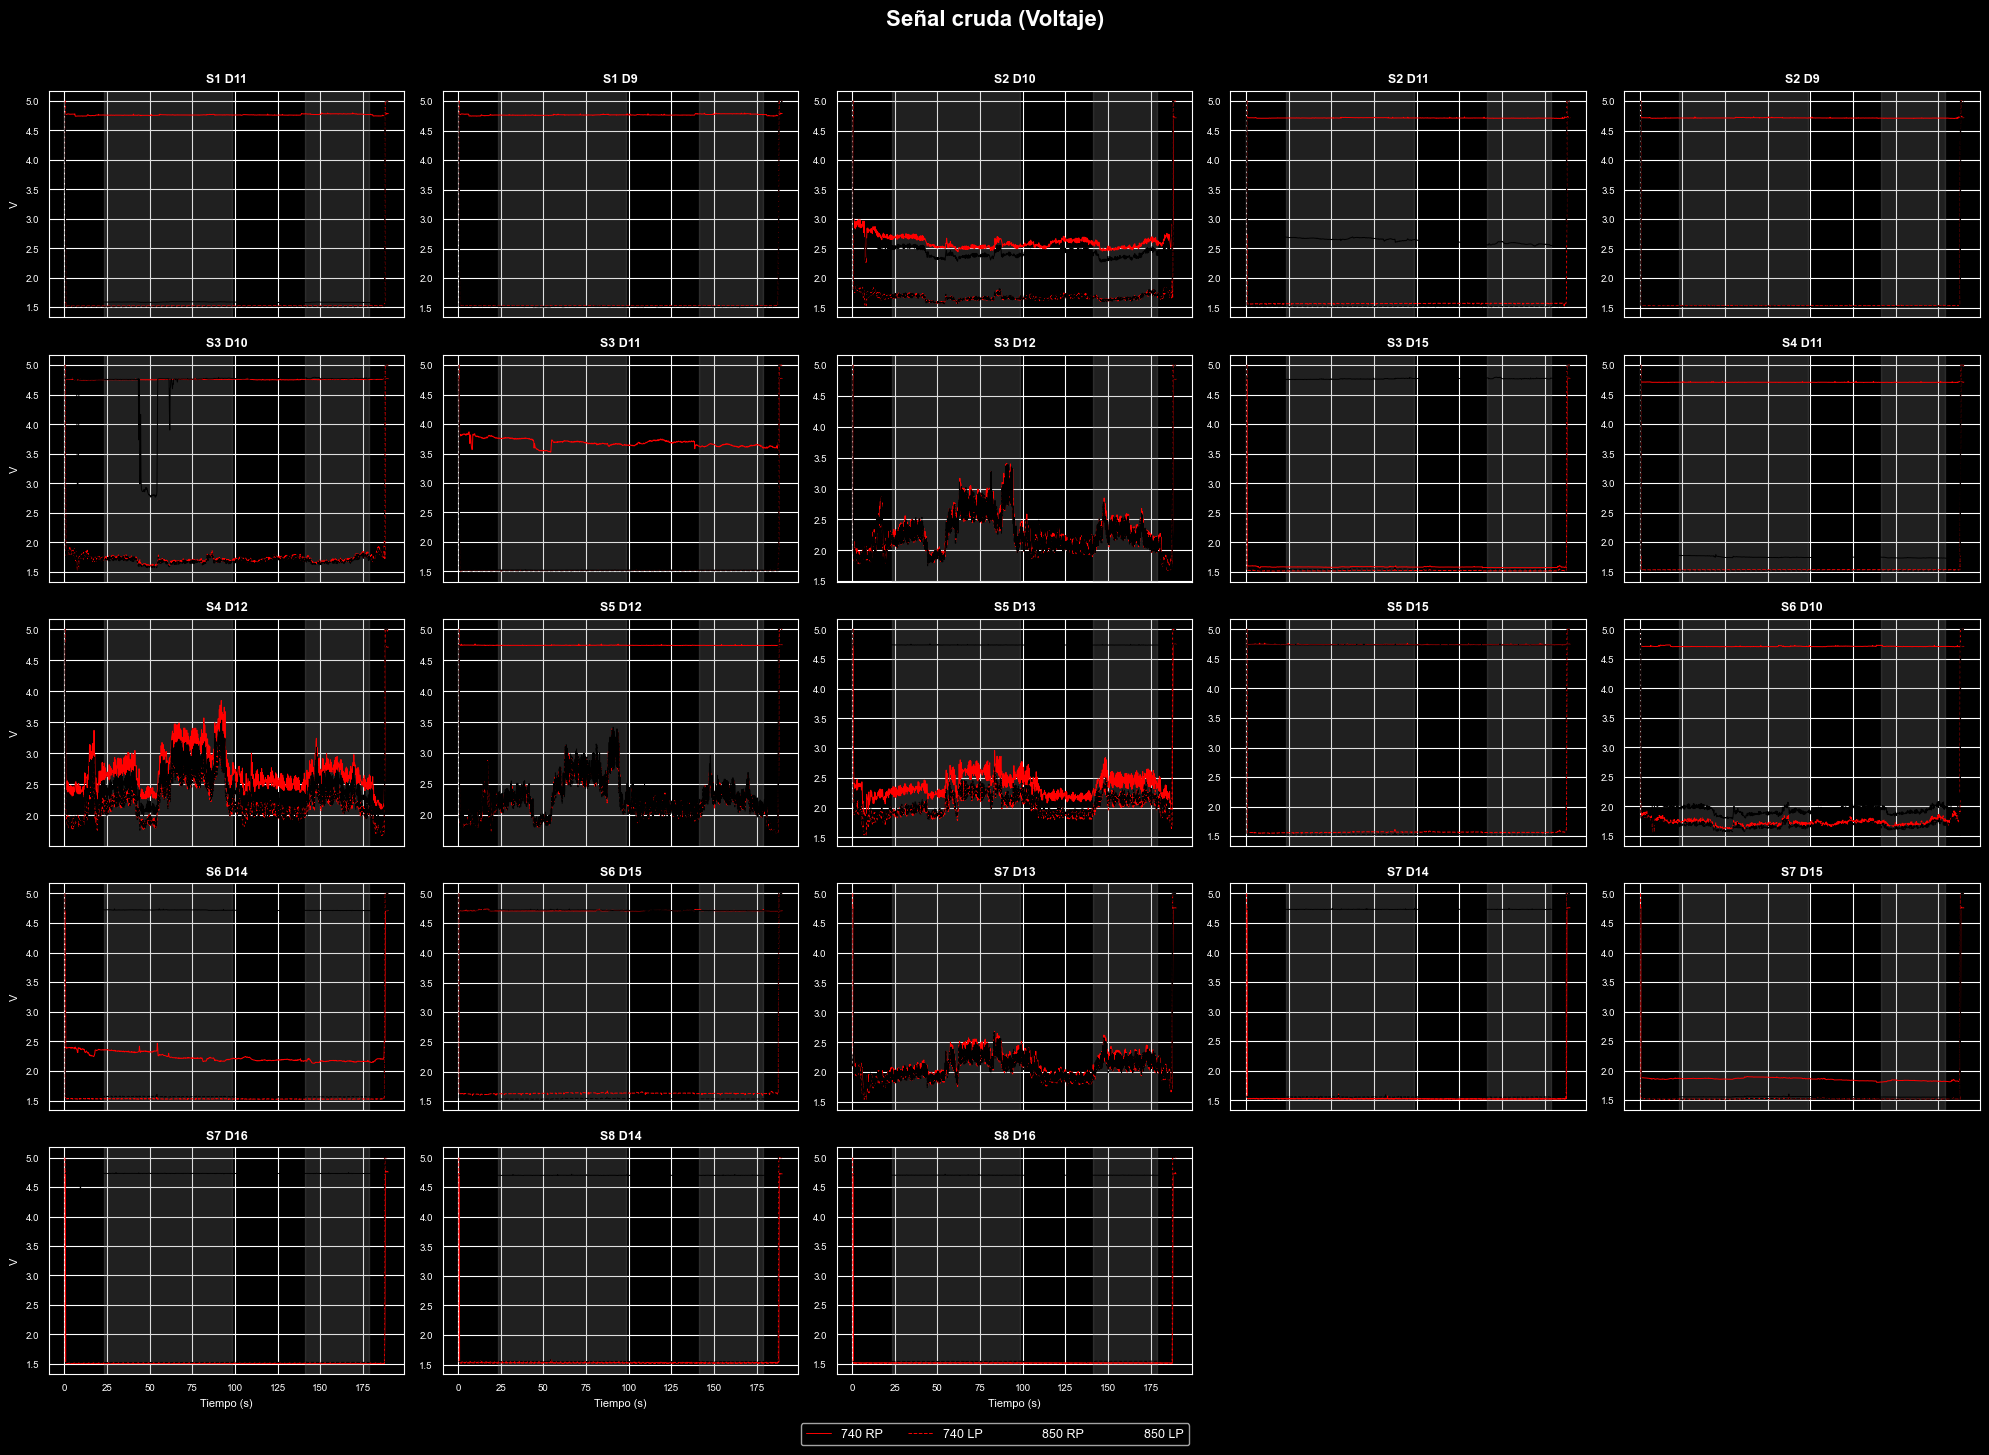

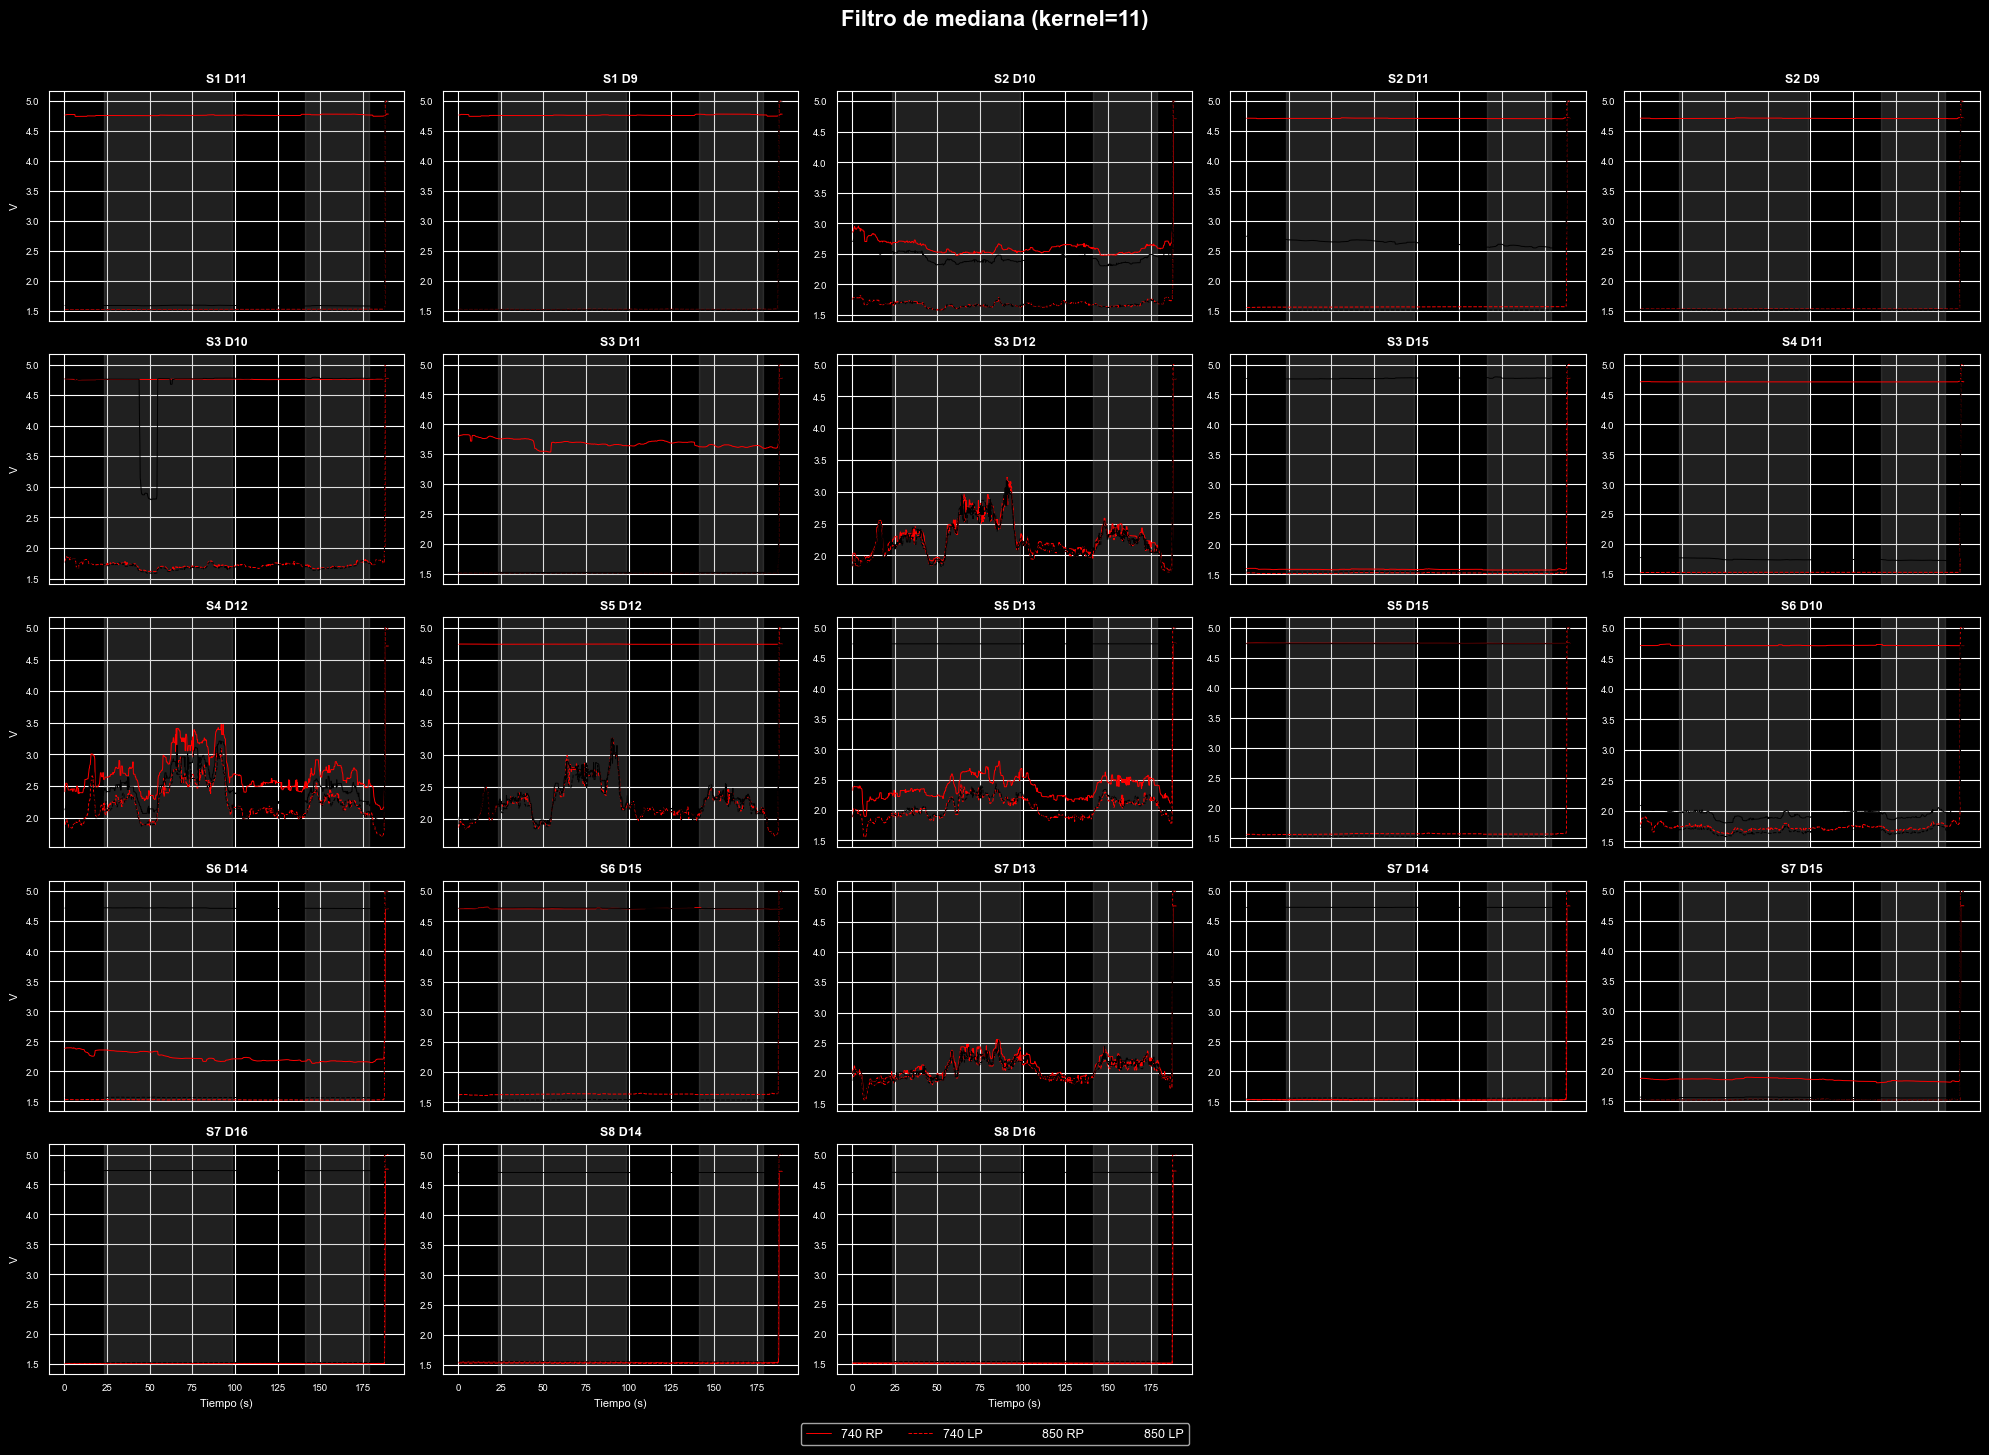

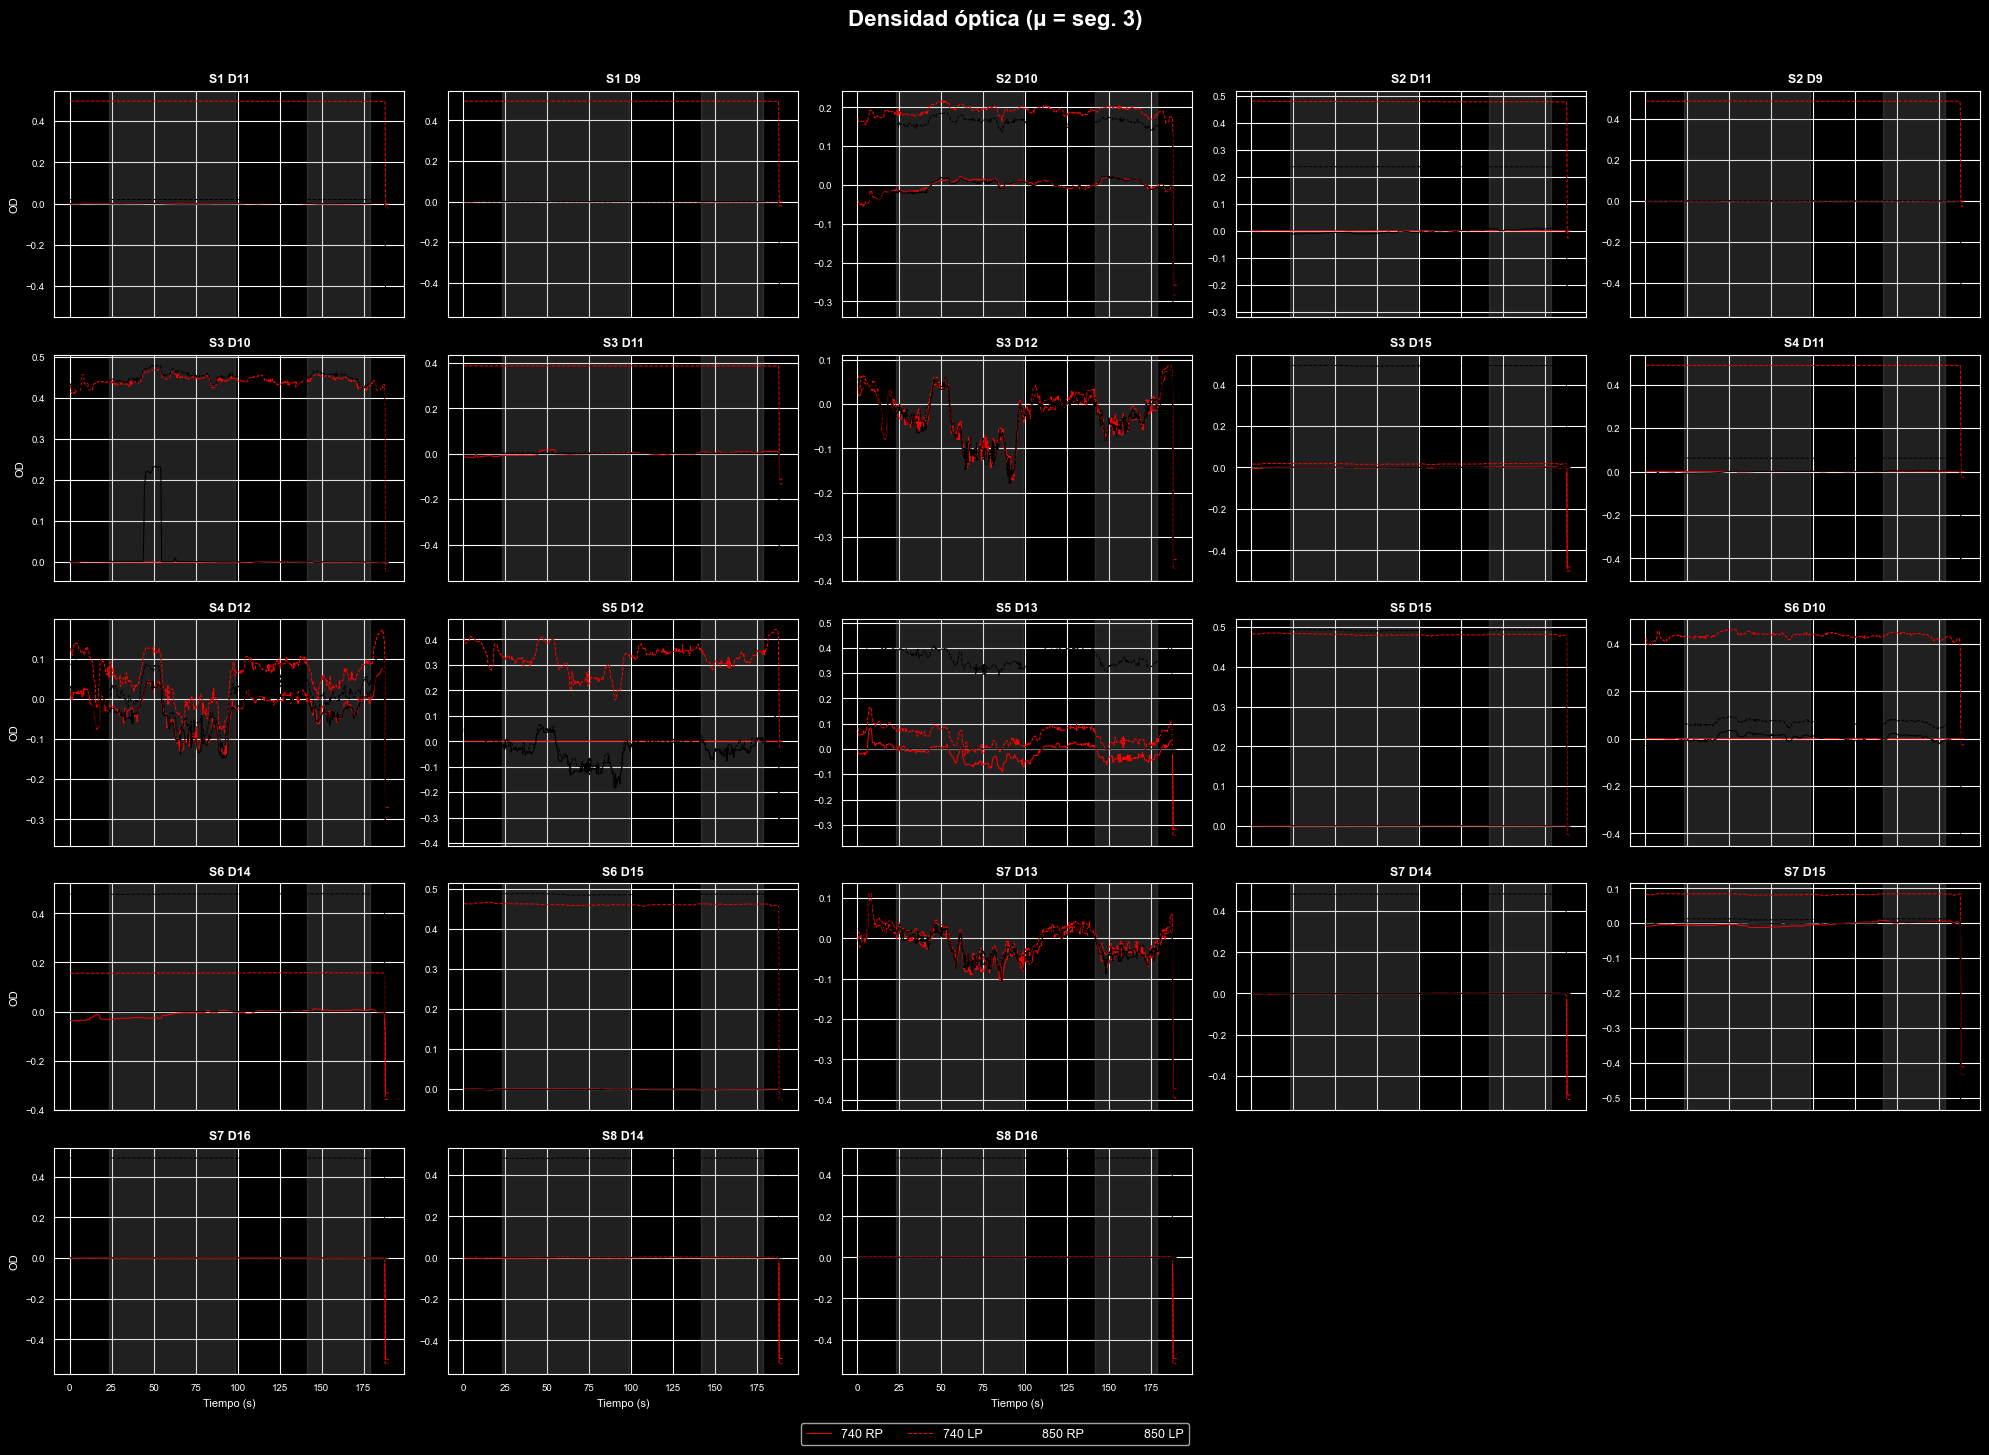

/var/folders/31/xwhnlymx3311fjz1p3vjrp1h0000gn/T/ipykernel_15809/3750836547.py:80: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
/opt/anaconda3/envs/mne/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


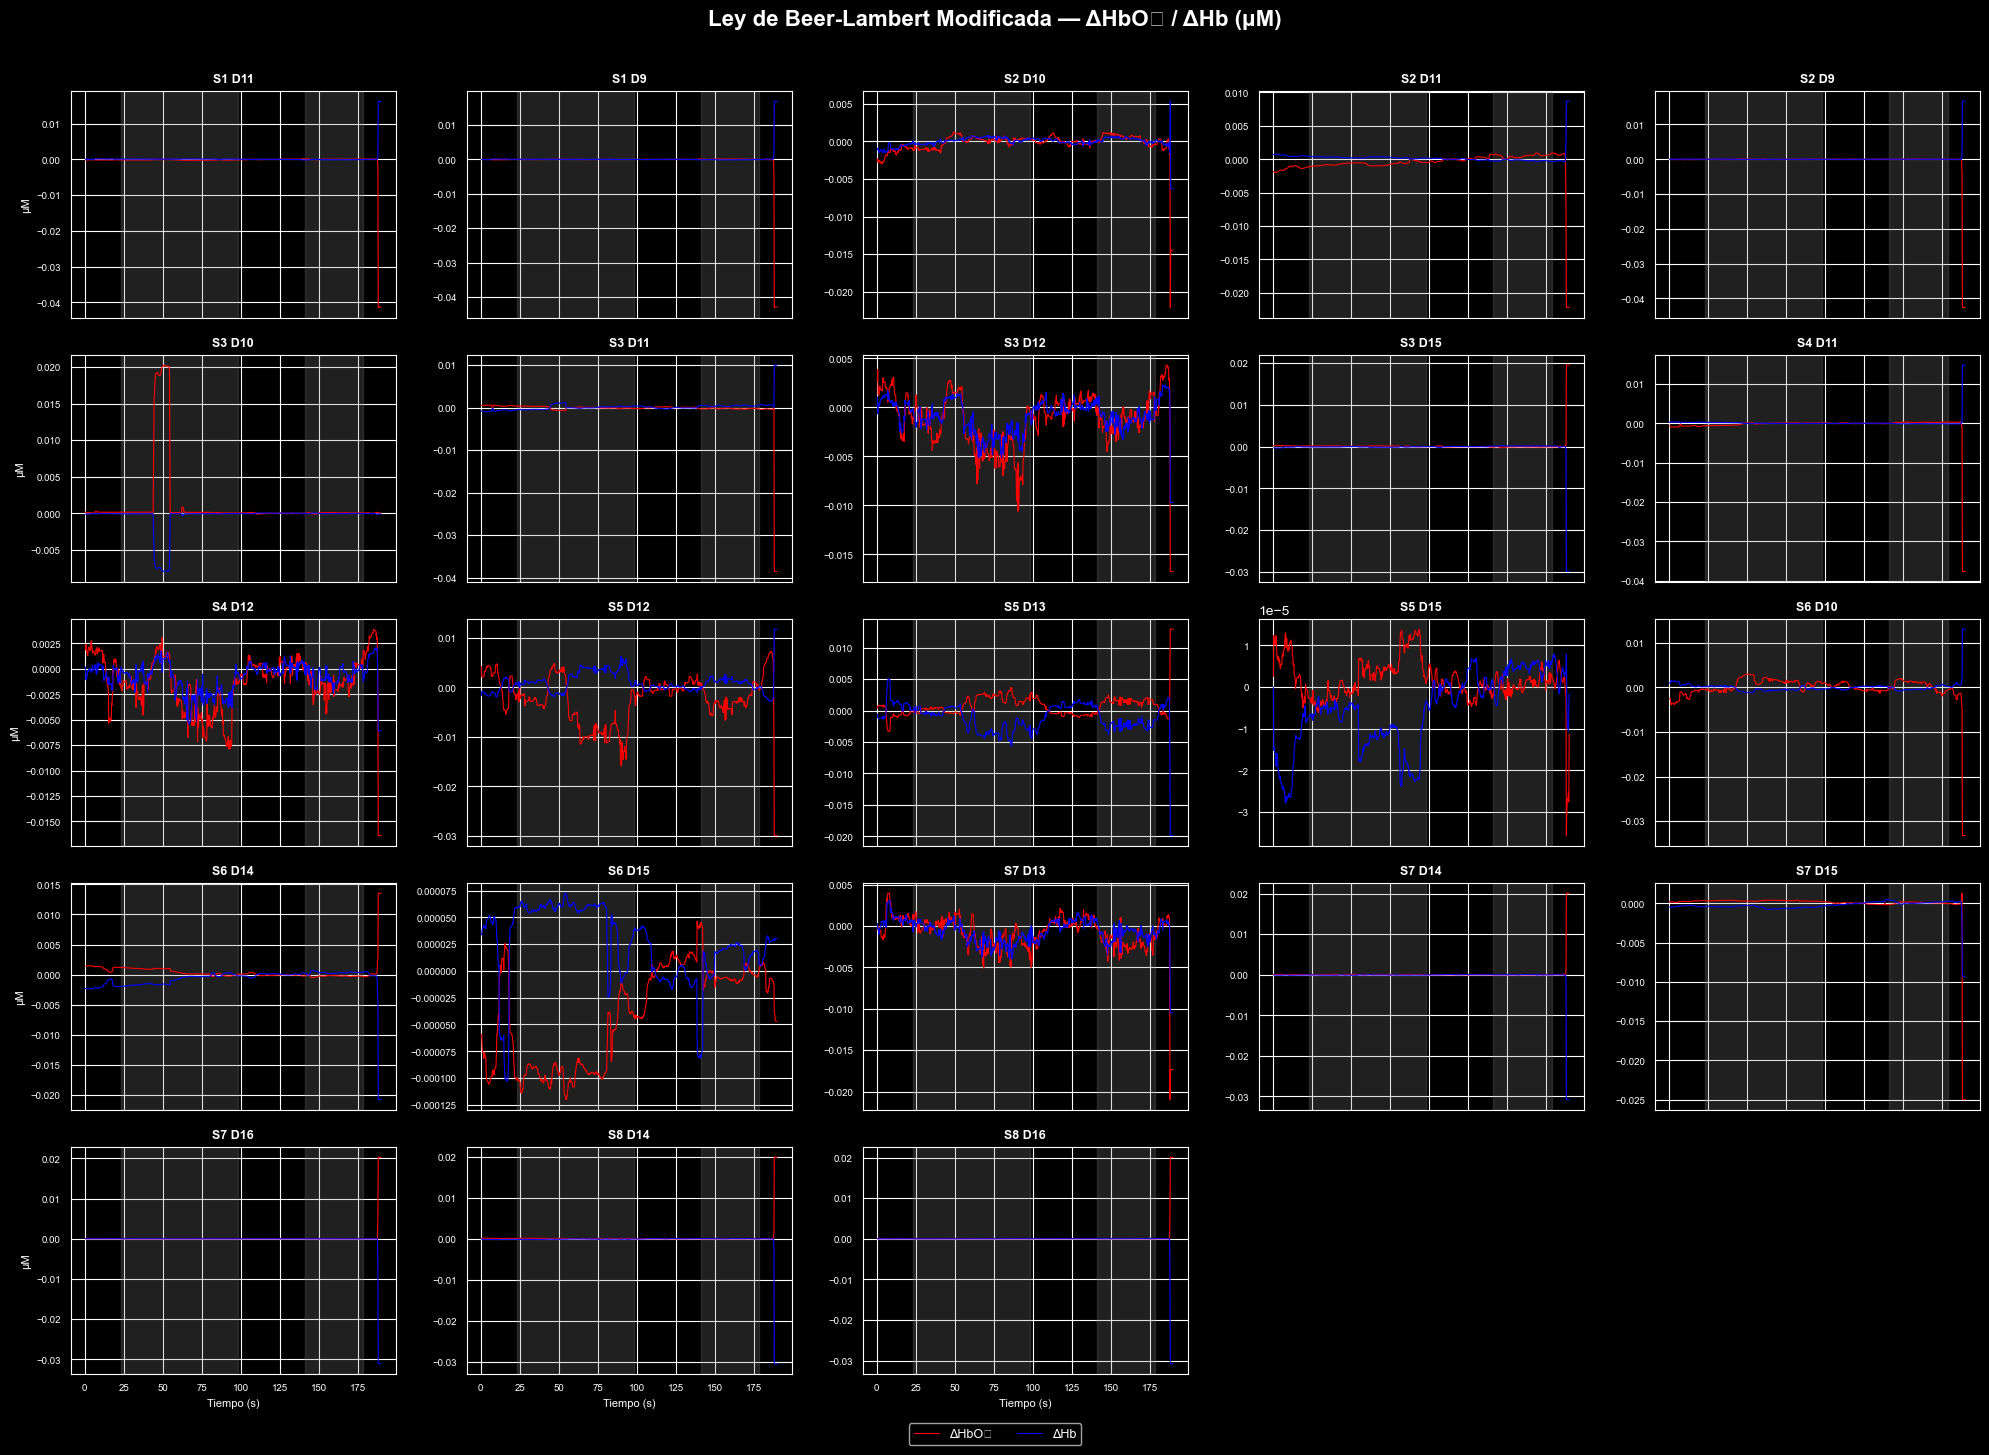

In [5]:
t = raw_data['time_elapsed'].values
n_pairs = len(pairs)
n_cols = 5
n_rows = int(np.ceil(n_pairs / n_cols))

# Preprocesar todos los pares
results = {pair: process_pair(raw_data, pair) for pair in pairs}

# ── Grids 1–3: señal cruda, filtrada, densidad óptica ────────────────────────
grid_configs = [
    ('Señal cruda (Voltaje)',                          'raw',  'V'),
    (f'Filtro de mediana (kernel={MEDIAN_KERNEL})',     'filt', 'V'),
    (f'Densidad óptica (μ = seg. {BASELINE_SEGMENT})', 'od',   'OD'),
]

for fig_title, data_key, ylabel in grid_configs:
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 4, n_rows * 2.8),
                             sharex=True, squeeze=False)
    fig.suptitle(fig_title, fontsize=16, fontweight='bold', y=1.01)

    for idx, pair in enumerate(pairs):
        row, col = divmod(idx, n_cols)
        ax = axes[row][col]
        res = results[pair]
        label = pair.upper().replace('_', ' ')

        ax.plot(t, res[data_key]['rp_740'], color='red',   linewidth=0.7, label='740 RP')
        ax.plot(t, res[data_key]['lp_740'], color='red',   linewidth=0.7, linestyle='--', label='740 LP')
        ax.plot(t, res[data_key]['rp_850'], color='black',  linewidth=0.7, label='850 RP')
        ax.plot(t, res[data_key]['lp_850'], color='black',  linewidth=0.7, linestyle='--', label='850 LP')
        shade_stimulus(ax, stimulus_spans, first_only_label=False)

        ax.set_title(label, fontsize=9, fontweight='bold')
        ax.tick_params(labelsize=7)
        if col == 0:
            ax.set_ylabel(ylabel, fontsize=8)
        if row == n_rows - 1:
            ax.set_xlabel('Tiempo (s)', fontsize=8)

    for idx in range(n_pairs, n_rows * n_cols):
        row, col = divmod(idx, n_cols)
        axes[row][col].set_visible(False)

    handles, labels = axes[0][0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', ncol=4, fontsize=9,
               bbox_to_anchor=(0.5, -0.02))
    plt.tight_layout()
    plt.show()

# ── Grid 4: ΔHbO₂ y ΔHb (MBLL) ──────────────────────────────────────────────
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 4, n_rows * 2.8),
                         sharex=True, squeeze=False)
fig.suptitle('Ley de Beer-Lambert Modificada — ΔHbO₂ / ΔHb (μM)',
             fontsize=16, fontweight='bold', y=1.01)

for idx, pair in enumerate(pairs):
    row, col = divmod(idx, n_cols)
    ax = axes[row][col]
    res = results[pair]
    label = pair.upper().replace('_', ' ')

    ax.plot(t, res['hbo2'], color='red',  linewidth=0.8, label='ΔHbO₂')
    ax.plot(t, res['hb'],   color='blue', linewidth=0.8, label='ΔHb')
    shade_stimulus(ax, stimulus_spans, first_only_label=False)

    ax.set_title(label, fontsize=9, fontweight='bold')
    ax.tick_params(labelsize=7)
    if col == 0:
        ax.set_ylabel('μM', fontsize=8)
    if row == n_rows - 1:
        ax.set_xlabel('Tiempo (s)', fontsize=8)

for idx in range(n_pairs, n_rows * n_cols):
    row, col = divmod(idx, n_cols)
    axes[row][col].set_visible(False)

handles, labels = axes[0][0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=3, fontsize=9,
           bbox_to_anchor=(0.5, -0.02))
plt.tight_layout()
plt.show()
